# Scaling analysis and HP performance

In [1]:
# Import settings?
nb_settings_path = "./settings.py"
with open(nb_settings_path) as f:
    code = f.read()
    exec(code)

In [2]:
import pandas as pd
from utils import FORMAT_N, FORMAT_D, N_color_map, D_color_map, N_ticks, D_ticks, SEQ_LEN


# Data

In [3]:
df = pd.read_csv("../data/loss_all_exps_post_annealing.csv")
df.head()

,job_name,N,N_approx,D,C,lr,gbsz,beta2,seed,iteration,train_samples,train_tokens,num_of_valid_seq,loss,loss_se
0,dense_130M_xm01_lr0.00025_gbsz16_beta20.99_12B,124455168,130000000.0,1.200000e+10,8.960772e+18,0.00025,16,0.99,1234,183106.0,2929696.0,1.200003e+10,204800.0,2.656725,0.0
1,dense_130M_xm01_lr0.00025_gbsz16_beta20.99_6B,124455168,130000000.0,6.000000e+09,4.480386e+18,0.00025,16,0.99,1234,91553.0,1464848.0,6.000017e+09,204800.0,2.721845,0.0
2,dense_130M_xm01_lr0.00025_gbsz32_beta20.99_12B,124455168,130000000.0,1.200000e+10,8.960772e+18,0.00025,32,0.99,1234,91553.0,2929696.0,1.200003e+10,204800.0,2.656892,0.0
3,dense_130M_xm01_lr0.00025_gbsz32_beta20.99_6B,124455168,130000000.0,6.000000e+09,4.480386e+18,0.00025,32,0.99,1234,45777.0,1464864.0,6.000083e+09,204800.0,2.729814,0.0
4,dense_130M_xm01_lr0.0005_gbsz1024_beta20.99_120B,124455168,130000000.0,1.200000e+11,8.960772e+19,0.00050,1024,0.99,1234,28611.0,29297664.0,1.200032e+11,204800.0,2.556560,0.0


# Quadratic fit

In [4]:
import statsmodels.api as sm
from utils_quadratic_2d import fit_2d_quadratic, plot_2d_quadratic, minima_2d_quadratic, plot_3d_quadratic_surface

In [5]:
df_fit = df.copy()
df_fit = df[
    (df.lr < 0.008)   # too spiky!
]

rows = []

for (N, D), g in df_fit.groupby(["N","D"]):

    # Fit
    m = fit_2d_quadratic(g, method='ols', y='loss', x='lr', z='gbsz')
    coef = m.params

    # Estimate minimum
    lr_star, gbsz_star, loss_star = minima_2d_quadratic(coef)

    # Store fitted params and estimated minimum
    rows.append({
        "N": N,
        "D": D,
        "coef": coef,
        "pvalues": m.pvalues,
        "r2": m.rsquared,
        "lr_star": lr_star,
        "gbsz_star": gbsz_star,
        "loss_star": loss_star,
    })

fit_2d_lr_gbsz = pd.DataFrame(rows)
fit_2d_lr_gbsz.head(2)

,N,D,coef,pvalues,r2,lr_star,gbsz_star,loss_star
0,47557632,6.000000e+09,"[4.3571207658502695, 0.19896126598354646, 0.00...","[2.402045275465236e-14, 3.122292937292146e-08,...",0.987092,0.001598,42.253112,2.925075
1,47557632,1.200000e+10,"[4.123444986243619, 0.16667904308556114, 0.006...","[6.146128497587531e-17, 1.1452998846075776e-07...",0.976952,0.001533,52.436837,2.871627


In [6]:
# plot_2d_quadratic(fit_2d_lr_gbsz, df_fit, save_path=f'../fig/smoothing/quadratic_2d/all_fits.png')

# Fit 1D quadratic for each GBSZ / LR
The previous code smooths out the minima and gives us optimal (LR,BSZ) for each (N,D). \
We might also want thave the optimal LR for each (N,D,GBSZ), so that we can for example fit LR* vs N,D for fixed GBSZ.

In [7]:
from utils_quadratic_1d import fit_1d_quadratic, minima_1d_quadratic

In [8]:
rows = []

for (N, D, gbsz), g in df.groupby(["N", "D", "gbsz"]):

    # Fit
    m = fit_1d_quadratic(g, x_col='lr')
    coef = m.params

    # Estimate minimum
    x_opt, loss_star = minima_1d_quadratic(coef)
    x_opt = 2 ** x_opt if x_opt is not None else None

    # Store fitted params + minimum
    rows.append({
        "N": N,
        "D": D,
        "gbsz": gbsz,
        "coef": coef,
        "pvalues": m.pvalues,
        "r2": m.rsquared,
        "lr_star": x_opt,
        "loss_star": loss_star,
    })

fit_1d_lr = pd.DataFrame(rows)
fit_1d_lr.head(2)

/Users/nico/miniforge3/envs/pawnic/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/nico/miniforge3/envs/pawnic/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/nico/miniforge3/envs/pawnic/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,N,D,gbsz,coef,pvalues,r2,lr_star,loss_star
0,47557632,6.000000e+09,16,"[3.976352717465005, 0.20612276286665043, 0.010...","[0.01100543914102265, 0.045260924990909515, 0....",0.998296,0.000873,2.929148
1,47557632,6.000000e+09,32,"[3.6166482149669434, 0.14531942853364122, 0.00...","[0.009748212038824523, 0.05169302851132503, 0....",0.993436,0.001373,2.925766


In [9]:
rows = []

for (N, D, lr), g in df.groupby(["N", "D", "lr"]):

    # Fit
    m = fit_1d_quadratic(g, x_col='gbsz')
    coef = m.params

    # Estimate minimum
    x_opt, loss_star = minima_1d_quadratic(coef)
    x_opt = 2 ** x_opt if x_opt is not None else None

    # Store fitted params + minimum
    rows.append({
        "N": N,
        "D": D,
        "lr": lr,
        "coef": coef,
        "pvalues": m.pvalues,
        "r2": m.rsquared,
        "gbsz_star": x_opt,
        "loss_star": loss_star,
    })

fit_1d_gbsz = pd.DataFrame(rows)
fit_1d_gbsz.head(2)

/Users/nico/miniforge3/envs/pawnic/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/nico/miniforge3/envs/pawnic/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/nico/miniforge3/envs/pawnic/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/nico/miniforge3/envs/pawnic/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,N,D,lr,coef,pvalues,r2,gbsz_star,loss_star
0,47557632,6.000000e+09,0.0005,"[3.0714760974999926, -0.0643677408333323, 0.00...","[0.007306397630279268, 0.1289492748866372, 0.0...",0.997303,18.690471,2.935524
1,47557632,6.000000e+09,0.0010,"[3.0659998964285755, -0.05865466785714446, 0.0...","[0.001457393147650779, 0.028547649423392708, 0...",0.999631,26.455438,2.927414


# Slice quadratic
We fitted a quadratic of loss vs lr and bsz. This allows us to smooth the optimal hyperparameters.
We are now interested in the evolution of lr (bsz) wrt N and D when fixing the bsz (lr).

A naive approach would be to fit a 1D quadratic for each bsz (lr). This is doable and occasionally gives good results.
However, we sometimes we have very few points! A more robust approach consists in considering the 2D quadratic model and **slice** it across known bsz dimensions.

In [10]:
from utils_quadratic_1d import slice_lr, slice_bsz, minima_1d_quadratic

In [11]:
rows = []

for (N, D, gbsz), g in df.groupby(["N", "D", "gbsz"]):
    
    fit_2d_coefs = fit_2d_lr_gbsz[(fit_2d_lr_gbsz.N == N) & (fit_2d_lr_gbsz.D == D)]['coef'].item()

    # Slice 2D quadratic
    coef = slice_lr(coef=fit_2d_coefs, bsz=gbsz)

    # Estimate minimum
    x_opt, loss_star = minima_1d_quadratic(coef)
    x_opt = 2 ** x_opt if x_opt is not None else None

    # Store fitted params + minimum
    rows.append({
        "N": N,
        "D": D,
        "gbsz": gbsz,
        "coef": coef,
        "lr_star": x_opt,
        "loss_star": loss_star,
    })

fit_2d_sliced_lr = pd.DataFrame(rows)
fit_2d_sliced_lr.head(2)

,N,D,gbsz,coef,lr_star,loss_star
0,47557632,6.000000e+09,16,"(3.727545049823734, 0.1536555648406877, 0.0074...",0.000761,2.931642
1,47557632,6.000000e+09,32,"(3.6085035955194815, 0.142329139554973, 0.0074...",0.001292,2.925613


In [12]:
rows = []

for (N, D, lr), g in df.groupby(["N", "D", "lr"]):
    
    fit_2d_coefs = fit_2d_lr_gbsz[(fit_2d_lr_gbsz.N == N) & (fit_2d_lr_gbsz.D == D)]['coef'].item()

    # Slice 2D quadratic
    coef = slice_bsz(coef=fit_2d_coefs, lr=lr)

    # Estimate minimum
    x_opt, loss_star = minima_1d_quadratic(coef)
    x_opt = 2 ** x_opt if x_opt is not None else None

    # Store fitted params + minimum
    rows.append({
        "N": N,
        "D": D,
        "lr": lr,
        "coef": coef,
        "gbsz_star": x_opt,
        "loss_star": loss_star,
    })

fit_2d_sliced_gbsz = pd.DataFrame(rows)
fit_2d_sliced_gbsz.head(2)

,N,D,lr,coef,gbsz_star,loss_star
0,47557632,6.000000e+09,0.0005,"(3.0671304685952396, -0.06387277236904933, 0.0...",17.920470,2.934162
1,47557632,6.000000e+09,0.0010,"(3.110860836119053, -0.07519919765476402, 0.00...",29.895321,2.926553


# Extract optimal HPs
For each N,D, we extract the following HPs:

- the best LR for each BSZ: $\eta^{\star}_B = \argmin_{\eta}(L)$
- the best BSZ for each LR: $B^{\star}_{\eta} = \argmin_{B}(L)$ for each $\eta$
- the best (LR,BSZ): $(\eta^{\star}, B^{\star}) = \argmin_{\eta, B}(L)$


We consider also the optimal $(\eta^{\star}_q, B^{\star}_q)$, which are the minima of the quadratic fit.

In [13]:
loss_key = 'loss'

# ------------------------------------------------------------------------------------------------
# OPTIMAL HPs

# Optimal lr for each (N, D, gbsz)
df_best_lr = df.loc[df.groupby(["N", "D", "gbsz"])[loss_key].idxmin()].reset_index(drop=True)

# Optimal gbsz for each (N, D, lr)
df_best_gbsz = df.loc[df.groupby(["N", "D", "lr"])[loss_key].idxmin()].reset_index(drop=True)

# Optimal (lr, gbsz) for each (N, D)
df_best_lr_gbsz = df.loc[df.groupby(["N", "D"])[loss_key].idxmin()].reset_index(drop=True)

# ------------------------------------------------------------------------------------------------
# HPs WITHIN TOL OF BEST
TOL = .1 / 100
def keep_within_tol(g, col=loss_key, tol=TOL):
    best = g[col].min()
    return g[g[col] <= best * (1 + tol)]

# Best lr for each (N, D, gbsz) within X%
df_tol_lr = df.groupby(["N", "D", "gbsz"], group_keys=False).apply(keep_within_tol).reset_index(drop=True)

# Best gbsz for each (N, D, lr) within X%
df_tol_gbsz = df.groupby(["N", "D", "lr"], group_keys=False).apply(keep_within_tol).reset_index(drop=True)

# Best (lr, gbsz) for each (N, D) within X%
df_tol_lr_gbsz = df.groupby(["N", "D"], group_keys=False).apply(keep_within_tol).reset_index(drop=True)

# Check: how many (lr, gbsz) pairs per (N, D)?
display(df_tol_lr_gbsz.groupby(["N", "D"]).size().unstack(fill_value=0))

# ------------------------------------------------------------------------------------------------
# BEST FROM QUADRATIC FITS

# Optimal lr for each (N, D, gbsz)
df_best_lr_smooth = fit_1d_lr.copy()
df_best_lr_smooth['C'] = 6 * df_best_lr_smooth['N'] * df_best_lr_smooth['D']
df_best_lr_smooth = df_best_lr_smooth.rename(columns={
    'lr_star': 'lr', 
    'loss_star': 'loss'
})
df_best_lr_smooth = df_best_lr_smooth[['N', 'D', 'C', 'lr', 'gbsz', 'loss']]
display(df_best_lr_smooth.head(2))

# Optimal gbsz for each (N, D, lr)
df_best_gbsz_smooth = fit_1d_gbsz.copy()
df_best_gbsz_smooth['C'] = 6 * df_best_gbsz_smooth['N'] * df_best_gbsz_smooth['D']
df_best_gbsz_smooth = df_best_gbsz_smooth.rename(columns={
    'gbsz_star': 'gbsz', 
    'loss_star': 'loss'
})
df_best_gbsz_smooth = df_best_gbsz_smooth[['N', 'D', 'C', 'lr', 'gbsz', 'loss']]
display(df_best_gbsz_smooth.head(2))

# Optimal (lr, gbsz) for each (N, D)
df_best_lr_gbsz_smooth = fit_2d_lr_gbsz.copy()
df_best_lr_gbsz_smooth['C'] = 6 * df_best_lr_gbsz_smooth['N'] * df_best_lr_gbsz_smooth['D']
df_best_lr_gbsz_smooth = df_best_lr_gbsz_smooth.rename(columns={
    'lr_star': 'lr',
    'gbsz_star': 'gbsz',
    'loss_star': 'loss'
})
df_best_lr_gbsz_smooth = df_best_lr_gbsz_smooth[['N', 'D', 'C', 'lr', 'gbsz', 'loss']]
display(df_best_lr_gbsz_smooth.head(2))

# ------------------------------------------------------------------------------------------------
# BEST FROM SLICED 2D QUADRATIC FIT

# Optimal lr for each (N, D, gbsz)
df_best_lr_sliced = fit_2d_sliced_lr.copy()
df_best_lr_sliced['C'] = 6 * df_best_lr_sliced['N'] * df_best_lr_sliced['D']
df_best_lr_sliced = df_best_lr_sliced.rename(columns={
    'lr_star': 'lr', 
    'loss_star': 'loss'
})
df_best_lr_sliced = df_best_lr_sliced[['N', 'D', 'C', 'lr', 'gbsz', 'loss']]
display(df_best_lr_sliced.head(2))

# Optimal gbsz for each (N, D, lr)
df_best_gbsz_sliced = fit_2d_sliced_gbsz.copy()
df_best_gbsz_sliced['C'] = 6 * df_best_gbsz_sliced['N'] * df_best_gbsz_sliced['D']
df_best_gbsz_sliced = df_best_gbsz_sliced.rename(columns={
    'gbsz_star': 'gbsz', 
    'loss_star': 'loss'
})
df_best_gbsz_sliced = df_best_gbsz_sliced[['N', 'D', 'C', 'lr', 'gbsz', 'loss']]
display(df_best_gbsz_sliced.head(2))


/var/folders/67/kpgjz7s90n7d32rwch6vy3f00000gn/T/ipykernel_91239/1193533429.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tol_lr = df.groupby(["N", "D", "gbsz"], group_keys=False).apply(keep_within_tol).reset_index(drop=True)
/var/folders/67/kpgjz7s90n7d32rwch6vy3f00000gn/T/ipykernel_91239/1193533429.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tol_gbsz = df.groupby(["N", "D", "lr"], gr

D,6.000000e+09,1.200000e+10,2.000000e+10,3.000000e+10,5.000000e+10,8.000000e+10,1.200000e+11,2.000000e+11,3.000000e+11
N,,,,,,,,,
47557632,4,6,4,3,5,4,3,6,5
124455168,2,5,2,2,3,5,3,1,3
301880320,1,1,3,3,4,4,3,3,2
588544000,1,4,3,3,2,4,5,3,2
983138304,1,1,1,1,1,1,1,3,4
1713504256,0,0,0,1,1,4,2,2,1


,N,D,C,lr,gbsz,loss
0,47557632,6.000000e+09,1.712075e+18,0.000873,16,2.929148
1,47557632,6.000000e+09,1.712075e+18,0.001373,32,2.925766


,N,D,C,lr,gbsz,loss
0,47557632,6.000000e+09,1.712075e+18,0.0005,18.690471,2.935524
1,47557632,6.000000e+09,1.712075e+18,0.0010,26.455438,2.927414


,N,D,C,lr,gbsz,loss
0,47557632,6.000000e+09,1.712075e+18,0.001598,42.253112,2.925075
1,47557632,1.200000e+10,3.424150e+18,0.001533,52.436837,2.871627


,N,D,C,lr,gbsz,loss
0,47557632,6.000000e+09,1.712075e+18,0.000761,16,2.931642
1,47557632,6.000000e+09,1.712075e+18,0.001292,32,2.925613


,N,D,C,lr,gbsz,loss
0,47557632,6.000000e+09,1.712075e+18,0.0005,17.920470,2.934162
1,47557632,6.000000e+09,1.712075e+18,0.0010,29.895321,2.926553


In [14]:
# Save best HP
df_best_lr.to_csv('../data/best_HPs/lr_min.csv', index=False)
df_best_gbsz.to_csv('../data/best_HPs/gbsz_min.csv', index=False)
df_best_lr_gbsz.to_csv('../data/best_HPs/lr_gbsz_min.csv', index=False)

# Save HP within TOL of best
df_best_lr.to_csv('../data/best_HPs/lr_within_tol.csv', index=False)
df_best_gbsz.to_csv('../data/best_HPs/gbsz_within_tol.csv', index=False)
df_best_lr_gbsz.to_csv('../data/best_HPs/lr_gbsz_within_tol.csv', index=False)

# Save HP from quadratic fit
df_best_lr_smooth.to_csv('../data/best_HPs/lr_min_smooth.csv', index=False)
df_best_gbsz_smooth.to_csv('../data/best_HPs/gbsz_min_smooth.csv', index=False)
df_best_lr_gbsz_smooth.to_csv('../data/best_HPs/lr_gbsz_min_smooth.csv', index=False)
df_best_lr_sliced.to_csv('../data/best_HPs/lr_min_sliced.csv', index=False)
df_best_gbsz_sliced.to_csv('../data/best_HPs/gbsz_min_sliced.csv', index=False)

# Save quadratic fits (parquet format since some columns have list entries)
fit_1d_lr.to_parquet('../data/quadratic_fits/fit_1d_lr.parquet', index=False)
fit_1d_gbsz.to_parquet('../data/quadratic_fits/fit_1d_gbsz.parquet', index=False)
fit_2d_lr_gbsz.to_parquet('../data/quadratic_fits/fit_2d_lr_gbsz.parquet', index=False)
fit_2d_sliced_lr.to_parquet('../data/quadratic_fits/fit_2d_sliced_lr.parquet', index=False)
fit_2d_sliced_gbsz.to_parquet('../data/quadratic_fits/fit_2d_sliced_gbsz.parquet', index=False)

# Plot smoothing

In [15]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from pathlib import Path
from utils import FORMAT_D, FORMAT_N
from utils import N_ticks, D_ticks, N_palette, D_palette, N_color_map, D_color_map, N_to_N_approx, N_approx_to_N

In [ ]:
from utils_plotting import plot_loss_grid

In [17]:
N_approx = 0.13e9
D = 120e9

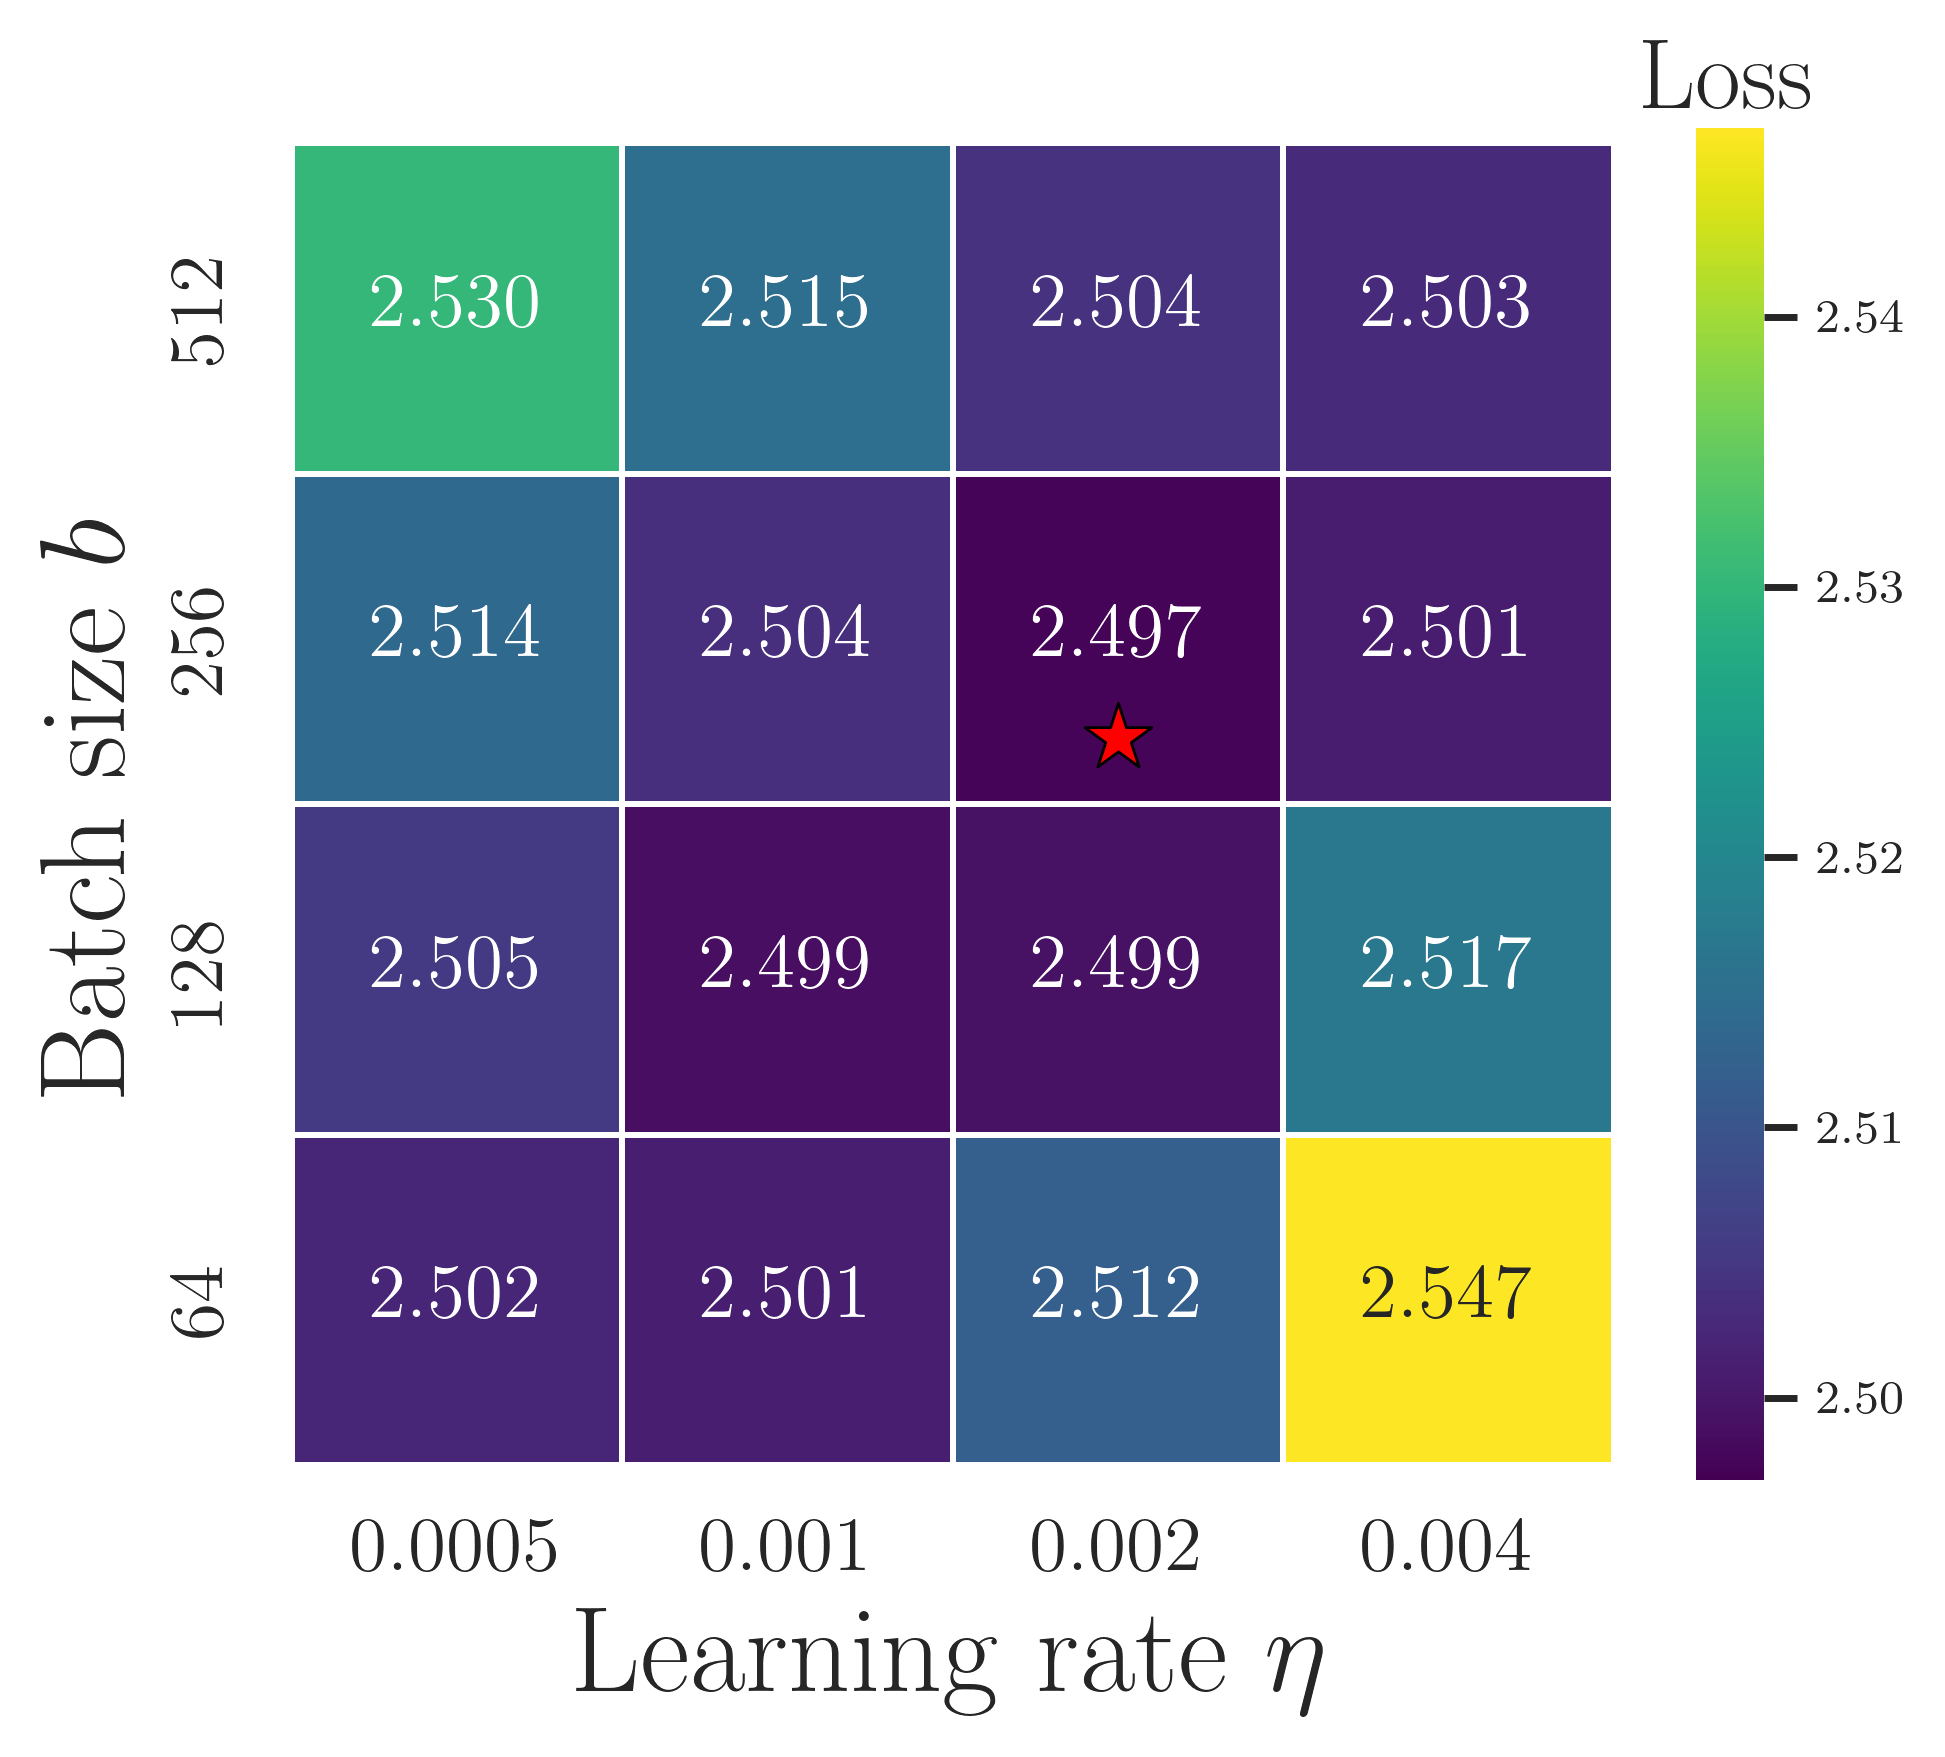

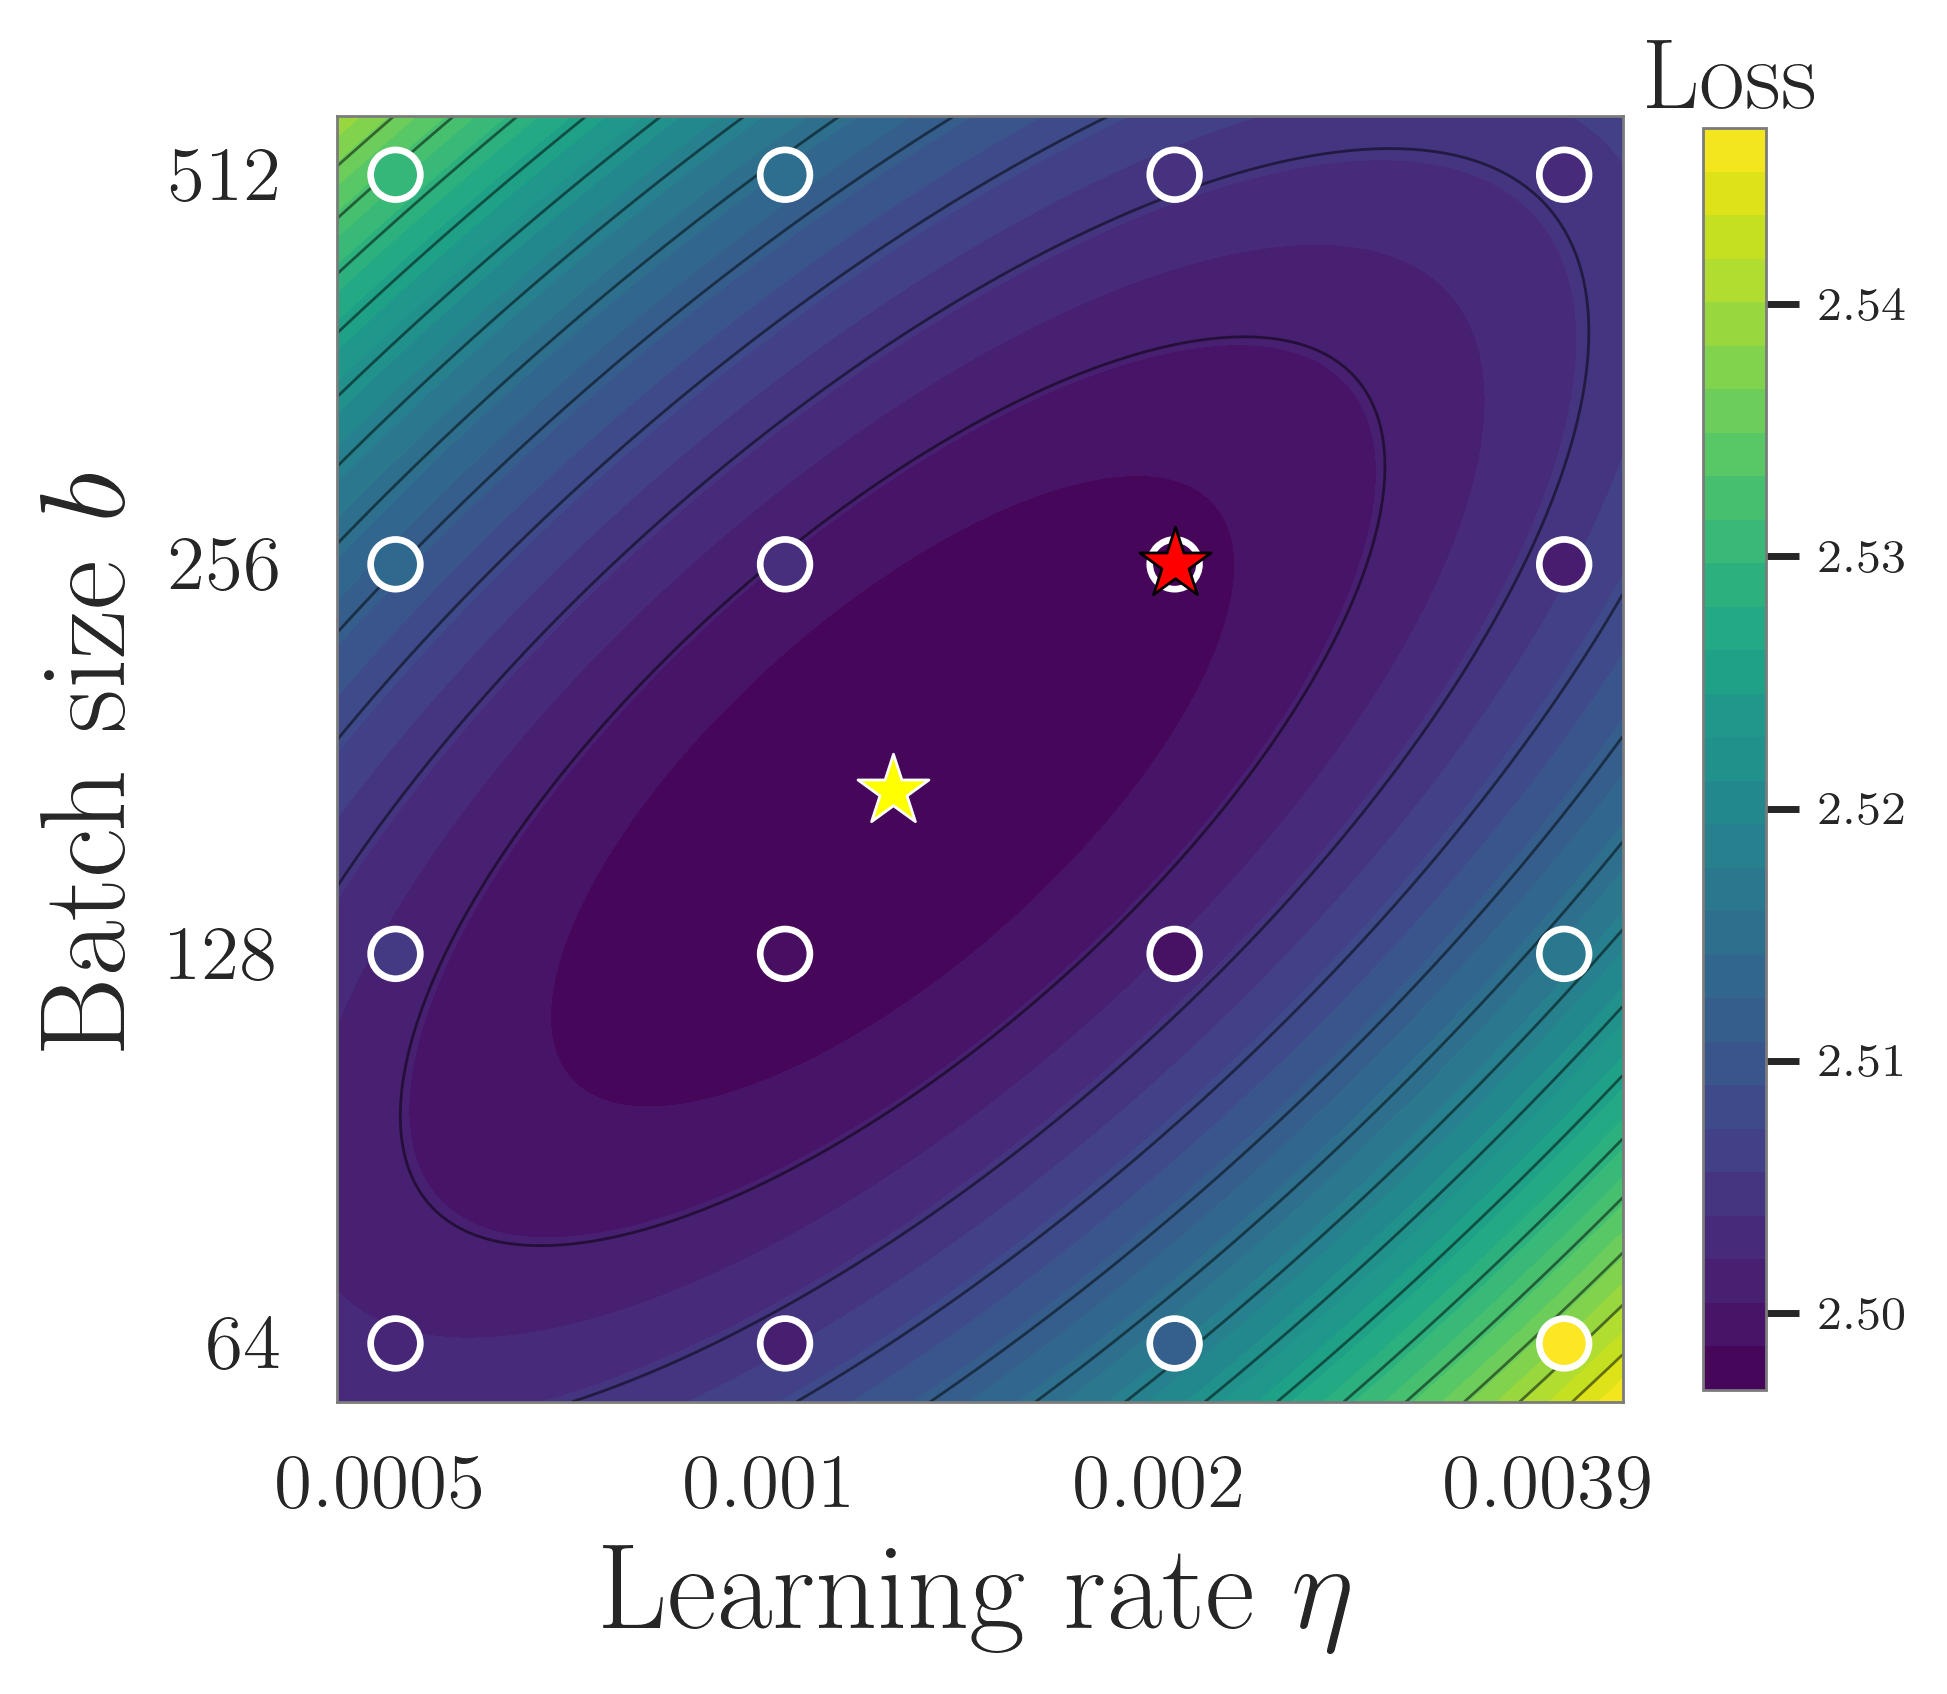

In [18]:
base_path = Path("../fig/smoothing/")

N = N_approx_to_N[N_approx]    
data = df[(df.N == N) & (df.D == D)]
fit = fit_2d_lr_gbsz[(fit_2d_lr_gbsz.N == N) & (fit_2d_lr_gbsz.D == D)].iloc[0]

save_path_grid = base_path / f"grid_{FORMAT_N(N)}_{FORMAT_D(D)}.pdf"
save_path_contour = base_path / f"contour_{FORMAT_N(N)}_{FORMAT_D(D)}.pdf"
save_path_grid.parent.mkdir(parents=True, exist_ok=True)
save_path_contour.parent.mkdir(parents=True, exist_ok=True)

plot_loss_grid(
    data,
    fit,
    lr_range=[0.0005, 0.004,],
    bsz_range=[64, 512],
    show=True,
    save_path_grid=save_path_grid,
    save_path_contour=save_path_contour,
)

In [19]:
N = N_approx_to_N[N_approx]
data = df[(df.N == N) & (df.D == D)]

fit_row = fit_2d_lr_gbsz[(fit_2d_lr_gbsz.N == N) & (fit_2d_lr_gbsz.D == D)].iloc[0]
save_path = base_path / f"surface_{FORMAT_N(N)}_{FORMAT_D(D)}.pdf"

plot_3d_quadratic_surface(data, fit_row, save_path=save_path)

# Plot Sliced Fit

In [20]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_sliced_quadratic(
    df,
    fit_df,
    fixed_filters,
    x_var,
    group_var,
    color_map,
    x_star_col,
    x_label,
    title,
    save_path=None,
    ylim_pad=0.01,
    ncols=3,
    show=False,
    figsize=(6, 5),
    bbox_to_anchor_2nd_legend=(0.0, 0.78),
):
    """
    Plot loss vs. x_var for a fixed set of variables, with one
    quadratic smoothing slice per value of group_var.

    Parameters
    ----------
    df : pd.DataFrame
        Raw measurements.

    fit_df : pd.DataFrame
        2D sliced quadratic fits. Must contain:
            - fixed/group columns
            - 'coef' = [c0, c1, c2]
            - x_star_col
            - 'loss_star'

    fixed_filters : dict
        Variables to hold fixed, e.g.
            {"N": N_val, "gbsz": gbsz}

    x_var : str
        Variable on the x-axis: "lr" or "gbsz".

    group_var : str
        Variable used to define separate curves/colors: "N" or "D".

    color_map : dict
        Mapping from group_var values to colors.

    x_star_col : str
        Column containing the estimated optimum:
            "lr_star" or "gbsz_star".

    x_label : str
        x-axis label.

    title : str
        Plot title.

    save_path : Path or str
        Where to save the figure.

    ylim_pad : float
        Amount added below the minimum loss.

    ncols : int
        Number of columns in the group legend.

    show : bool
        Whether to display the figure.

    figsize : tuple
        Figure size.
    """

    # ============================================================
    # Filter raw data and fits
    # ============================================================

    raw = df.copy()
    fits = fit_df.copy()

    for key, value in fixed_filters.items():
        raw = raw[raw[key] == value]
        fits = fits[fits[key] == value]

    if raw.empty or fits.empty:
        return None

    # ============================================================
    # Set up
    # ============================================================

    group_values = sorted(raw[group_var].unique())

    fig, ax = plt.subplots(figsize=figsize)

    # ============================================================
    # Plot each group
    # ============================================================

    plotted_groups = []

    for group_value in group_values:

        sub_raw = raw[raw[group_var] == group_value]
        sub_fit = fits[fits[group_var] == group_value]

        if sub_raw.empty or sub_fit.empty:
            continue

        row = sub_fit.iloc[0]

        c0, c1, c2 = row["coef"]
        x_star = row[x_star_col]
        loss_star = row["loss_star"]

        color = color_map[group_value]

        # --------------------------------------------------------
        # Measured loss
        # --------------------------------------------------------

        ax.scatter(
            sub_raw[x_var],
            sub_raw["loss"],
            color=color,
            edgecolors="black",
            linewidths=0.2,
            alpha=0.8,
            zorder=3,
        )

        # --------------------------------------------------------
        # Quadratic smoothing slice
        # --------------------------------------------------------

        x_vals = np.linspace(
            np.log2(sub_raw[x_var].min()),
            np.log2(sub_raw[x_var].max()),
            200,
        )

        x_plot = 2 ** x_vals

        loss_pred = (
            c0
            + c1 * x_vals
            + c2 * x_vals**2
        )

        ax.plot(
            x_plot,
            loss_pred,
            color=color,
            linewidth=0.8,
            zorder=2,
        )

        # --------------------------------------------------------
        # Estimated optimum
        # --------------------------------------------------------

        ax.scatter(
            x_star,
            loss_star,
            color=color,
            marker="*",
            edgecolors="black",
            linewidths=0.2,
            s=60,
            zorder=4,
        )

        plotted_groups.append(group_value)

    # ============================================================
    # Axes
    # ============================================================

    ax.set_xscale("log", base=2)

    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(r"Validation Loss $\downarrow$", fontsize=12)
    ax.set_title(title, fontsize=12)

    ax.set_xlim(
        raw[x_var].min() / 1.1,
        raw[x_var].max() * 1.1,
    )

    ax.set_ylim(
        raw["loss"].min() - ylim_pad,
        raw["loss"].max() + ylim_pad
        if ylim_pad is not None
        else None,
    )

    # ============================================================
    # Legend 1: group values
    # ============================================================

    group_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markersize=5,
            markerfacecolor=color_map[group_value],
            markeredgecolor='black',
            markeredgewidth=0.2,
        )
        for group_value in plotted_groups
    ]

    group_labels = [
        FORMAT_N(group_value)
        if group_var == "N"
        else FORMAT_D(group_value)
        for group_value in plotted_groups
    ]

    group_title = r"$N$" if group_var == "N" else r"$D$"

    legend_group = ax.legend(
        handles=group_handles,
        labels=group_labels,
        title=group_title,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.0),
        fontsize=8,
        frameon=True,
        facecolor="white",
        edgecolor="0.8",
        framealpha=1.0,
        ncols=ncols,
        handlelength=1.5,
        handletextpad=0.4,
        columnspacing=1.0,
        borderpad=0.7,
        labelspacing=0.4,
    )

    ax.add_artist(legend_group)

    # ============================================================
    # Legend 2: measured vs. smoothing
    # ============================================================

    style_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markersize=5,
            color="darkgrey",
            markerfacecolor="darkgrey",
            markeredgecolor="black",
            markeredgewidth=0.2,
        ),
        Line2D(
            [0],
            [0],
            color="darkgrey",
            linewidth=1.2,
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            linestyle="None",
            markersize=8,
            color="darkgrey",
            markerfacecolor="darkgrey",
            markeredgecolor="black",
            markeredgewidth=0.2,
        ),
    ]

    style_labels = [
        "Measured loss",
        "2D smoothing slice",
        "Estimated optimum",
    ]

    legend_style = ax.legend(
        handles=style_handles,
        labels=style_labels,
        loc="upper left",
        bbox_to_anchor=bbox_to_anchor_2nd_legend,
        fontsize=8,
        frameon=True,
        facecolor="white",
        edgecolor="0.8",
        framealpha=1.0,
        handlelength=2.0,
        handletextpad=0.5,
        borderpad=0.6,
        labelspacing=0.4,
    )

    ax.add_artist(legend_style)

    # ============================================================
    # Save
    # ============================================================

    plt.tight_layout()

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_path,
            dpi=400,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

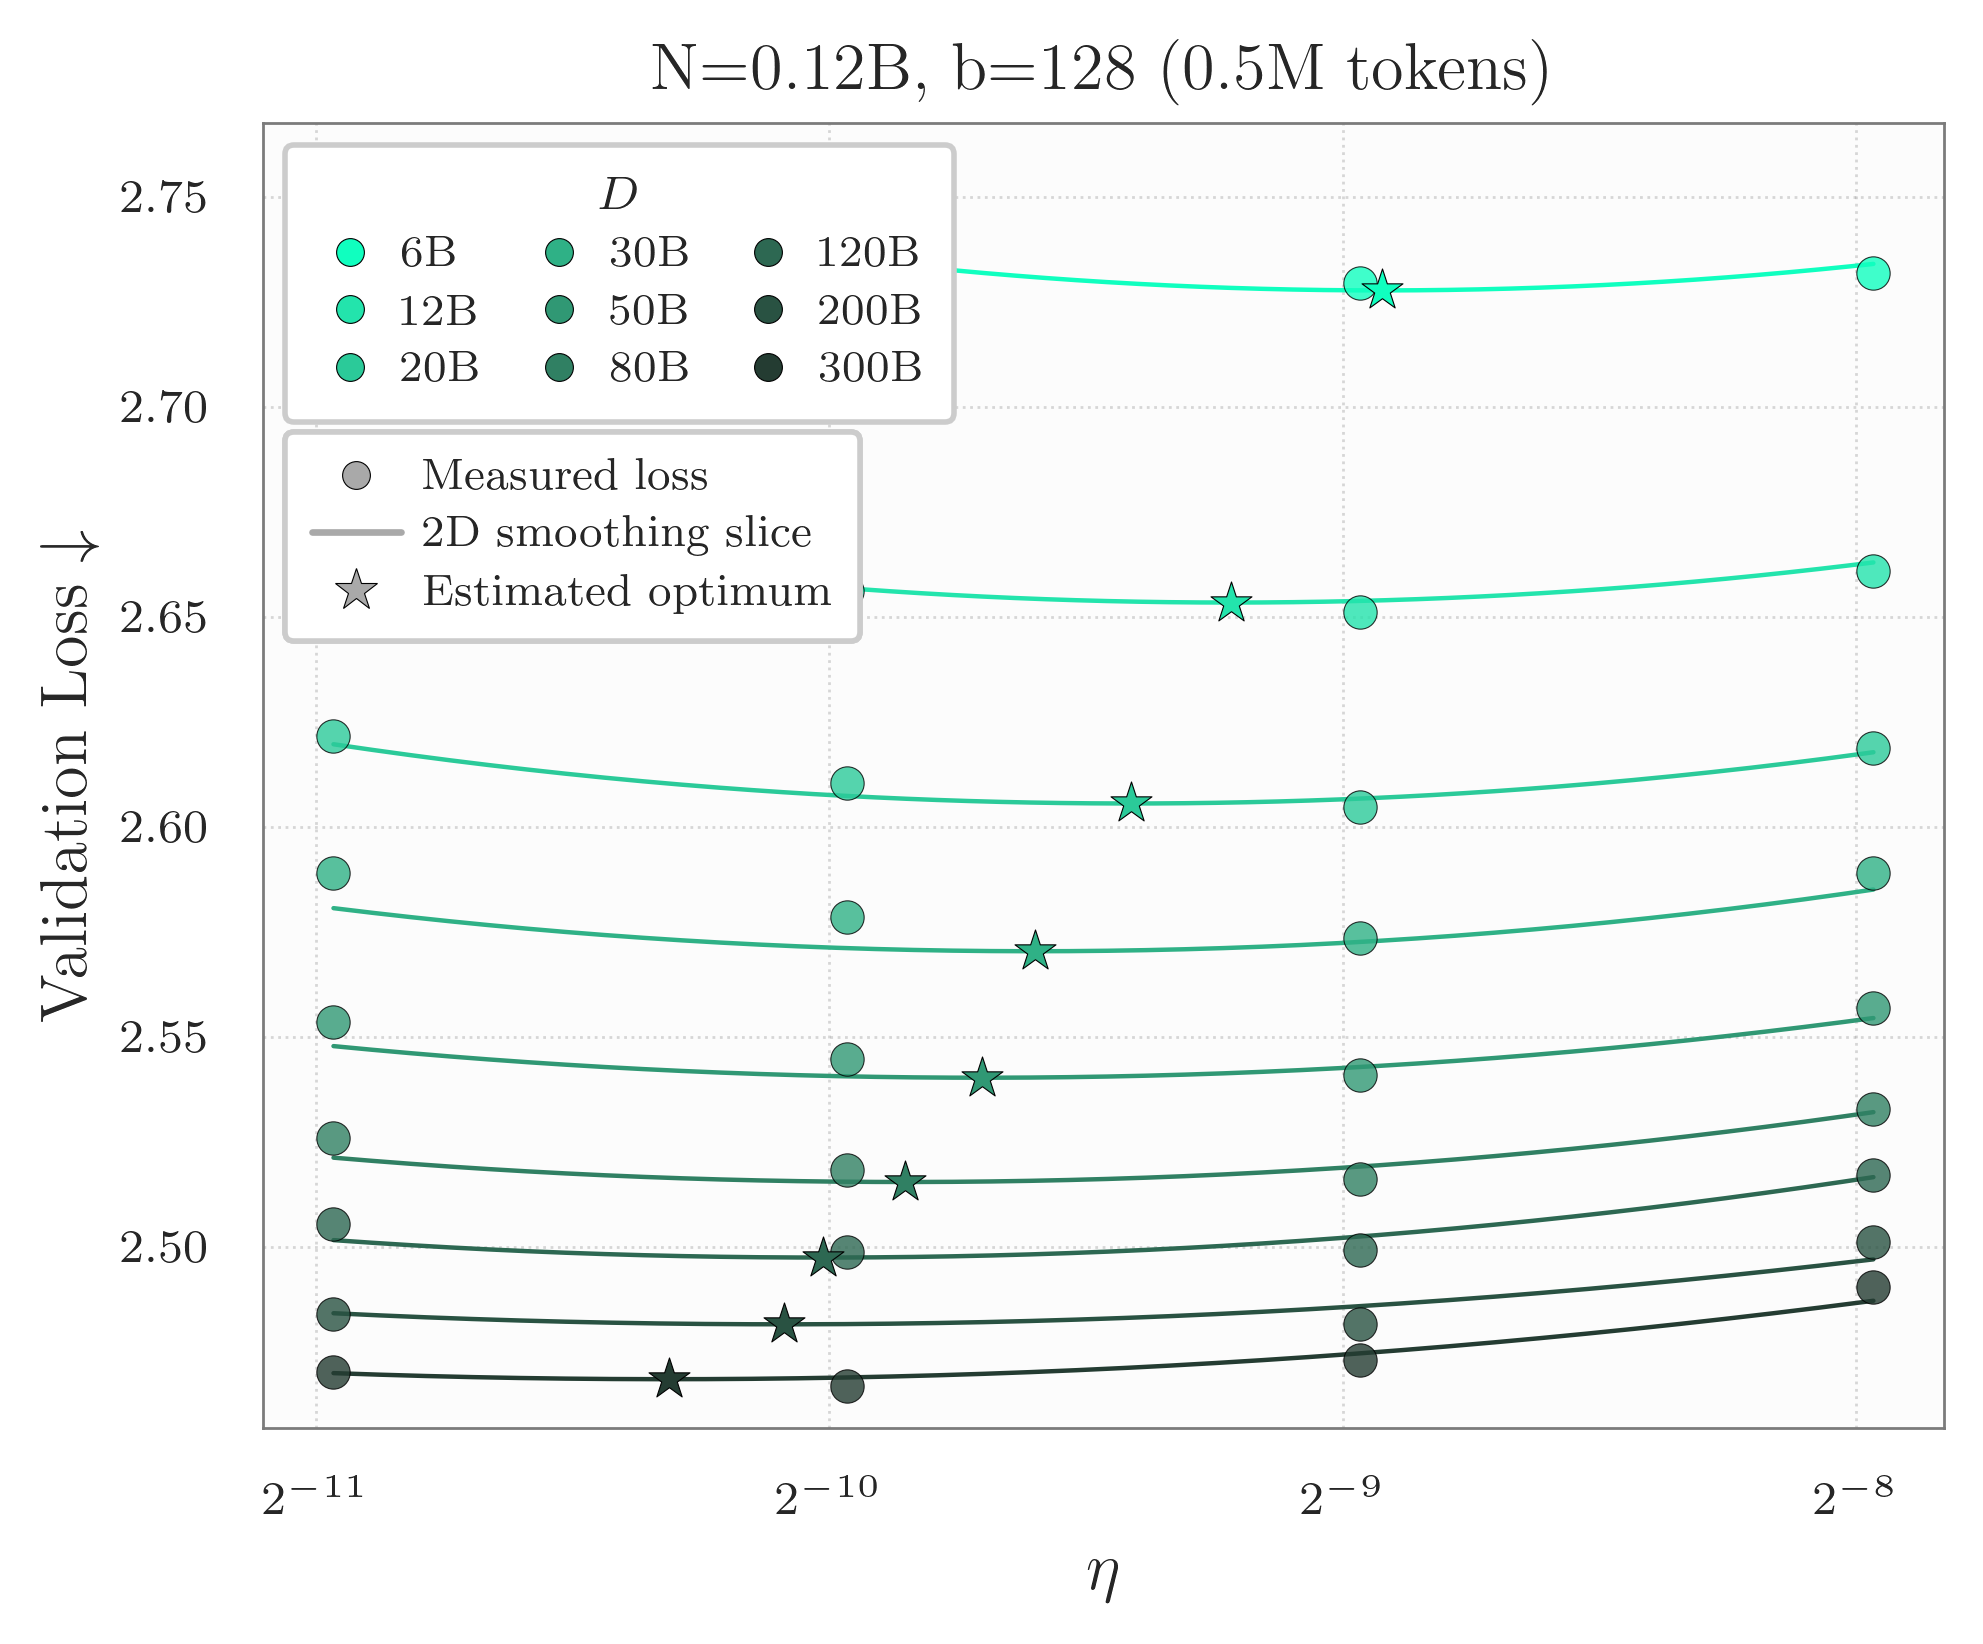

(<Figure size 2000x1660 with 1 Axes>,
 <Axes: title={'center': 'N=0.12B, b=128 (0.5M tokens)'}, xlabel='$\\eta$', ylabel='Validation Loss $\\downarrow$'>)

In [21]:
# ------------------------------------------
# Loss vs LR, color by D
# ------------------------------------------

N_val = N_approx_to_N[0.13e9]
gbsz = 128

fit_df = fit_2d_sliced_lr
fixed_filters = {"N": N_val, "gbsz": gbsz}

group_var = "D"
color_map = D_color_map
x_star_col = "lr_star"
x_label = r"$\eta$"
title = f"N={FORMAT_N(N_val)}, b={gbsz} ({gbsz * SEQ_LEN / 1e6:.1f}M tokens)"

save_path = '../fig/smoothing/loss_vs_LR_hue_D.pdf'

plot_sliced_quadratic(
    df=df,
    fit_df=fit_df,
    fixed_filters=fixed_filters,
    x_var="lr",
    group_var=group_var,
    color_map=color_map,
    x_star_col=x_star_col,
    x_label=x_label,
    title=title,
    save_path=save_path,
    ylim_pad=0.01,
    show=True,
    figsize=(5,4.15),
    bbox_to_anchor_2nd_legend=(0.0, 0.78)
)

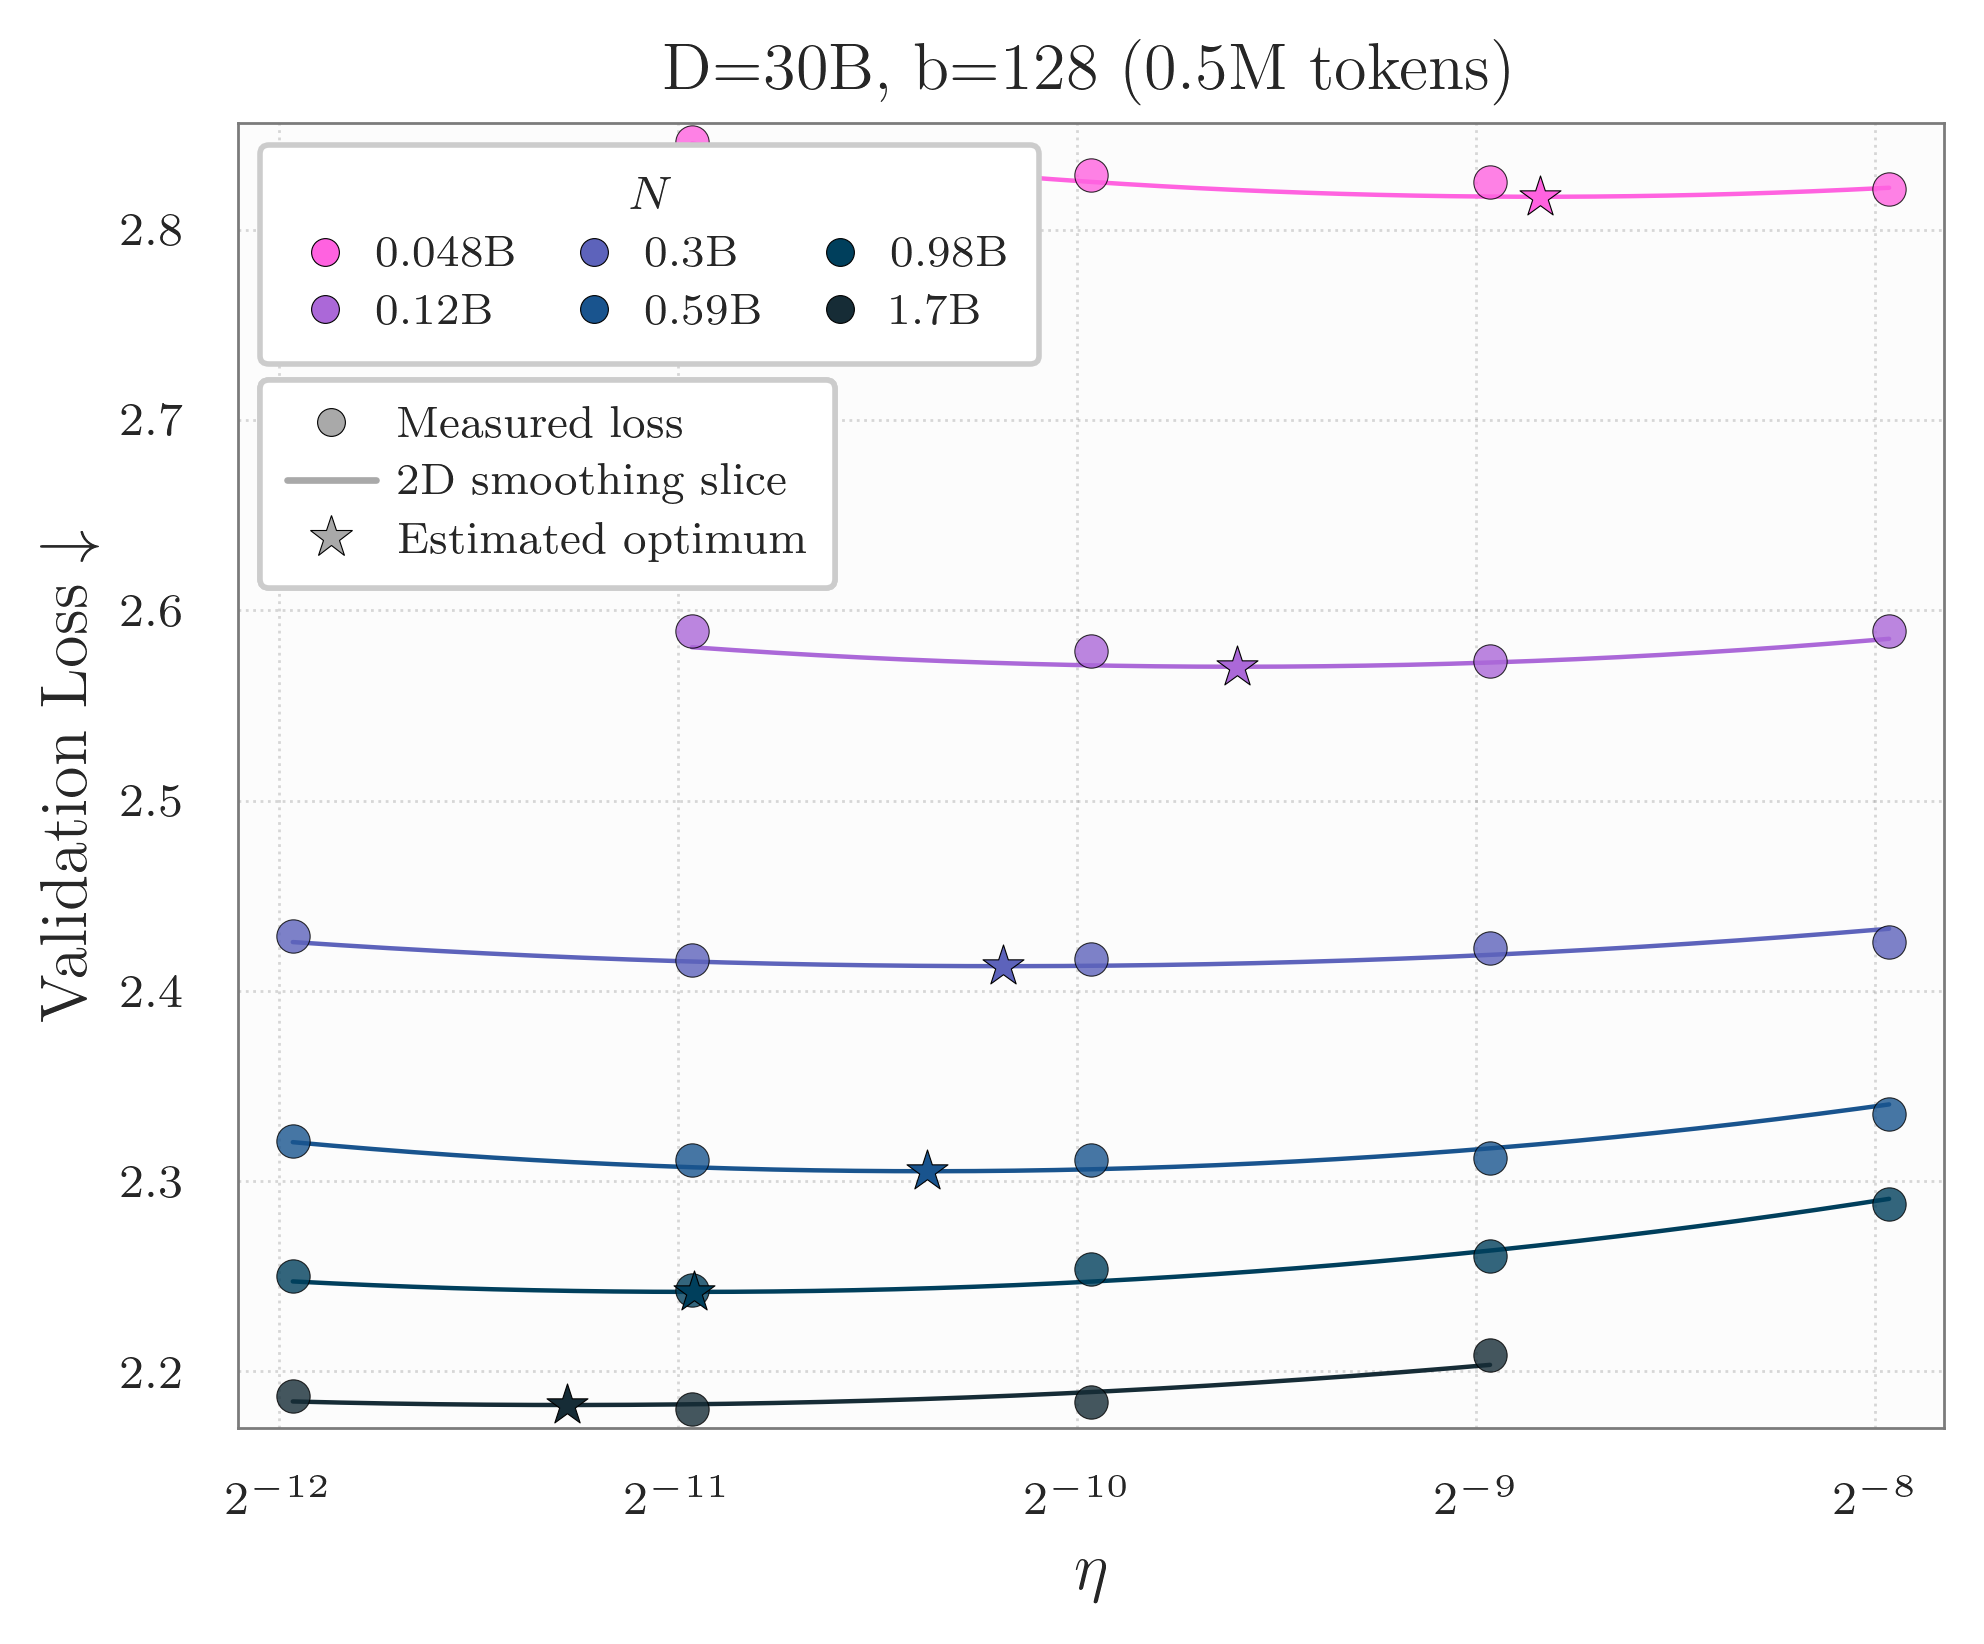

(<Figure size 2000x1660 with 1 Axes>,
 <Axes: title={'center': 'D=30B, b=128 (0.5M tokens)'}, xlabel='$\\eta$', ylabel='Validation Loss $\\downarrow$'>)

In [22]:
# ------------------------------------------
# Loss vs LR, color by N
# ------------------------------------------

D_val = 30e9
gbsz = 128

fit_df = fit_2d_sliced_lr
fixed_filters = {"D": D_val, "gbsz": gbsz}

group_var="N"
color_map = N_color_map
x_star_col = "lr_star"
x_label = r"$\eta$"
title = f"D={FORMAT_D(D_val)}, b={gbsz} ({gbsz * SEQ_LEN / 1e6:.1f}M tokens)"

save_path = '../fig/smoothing/loss_vs_LR_hue_N.pdf'

plot_sliced_quadratic(
    df=df,
    fit_df=fit_df,
    fixed_filters=fixed_filters,
    x_var="lr",
    group_var=group_var,
    color_map=color_map,
    x_star_col=x_star_col,
    x_label=x_label,
    title=title,
    save_path=save_path,
    ylim_pad=0.01,
    show=True,
    figsize=(5,4.15),
    bbox_to_anchor_2nd_legend=(0.0, 0.82)
)

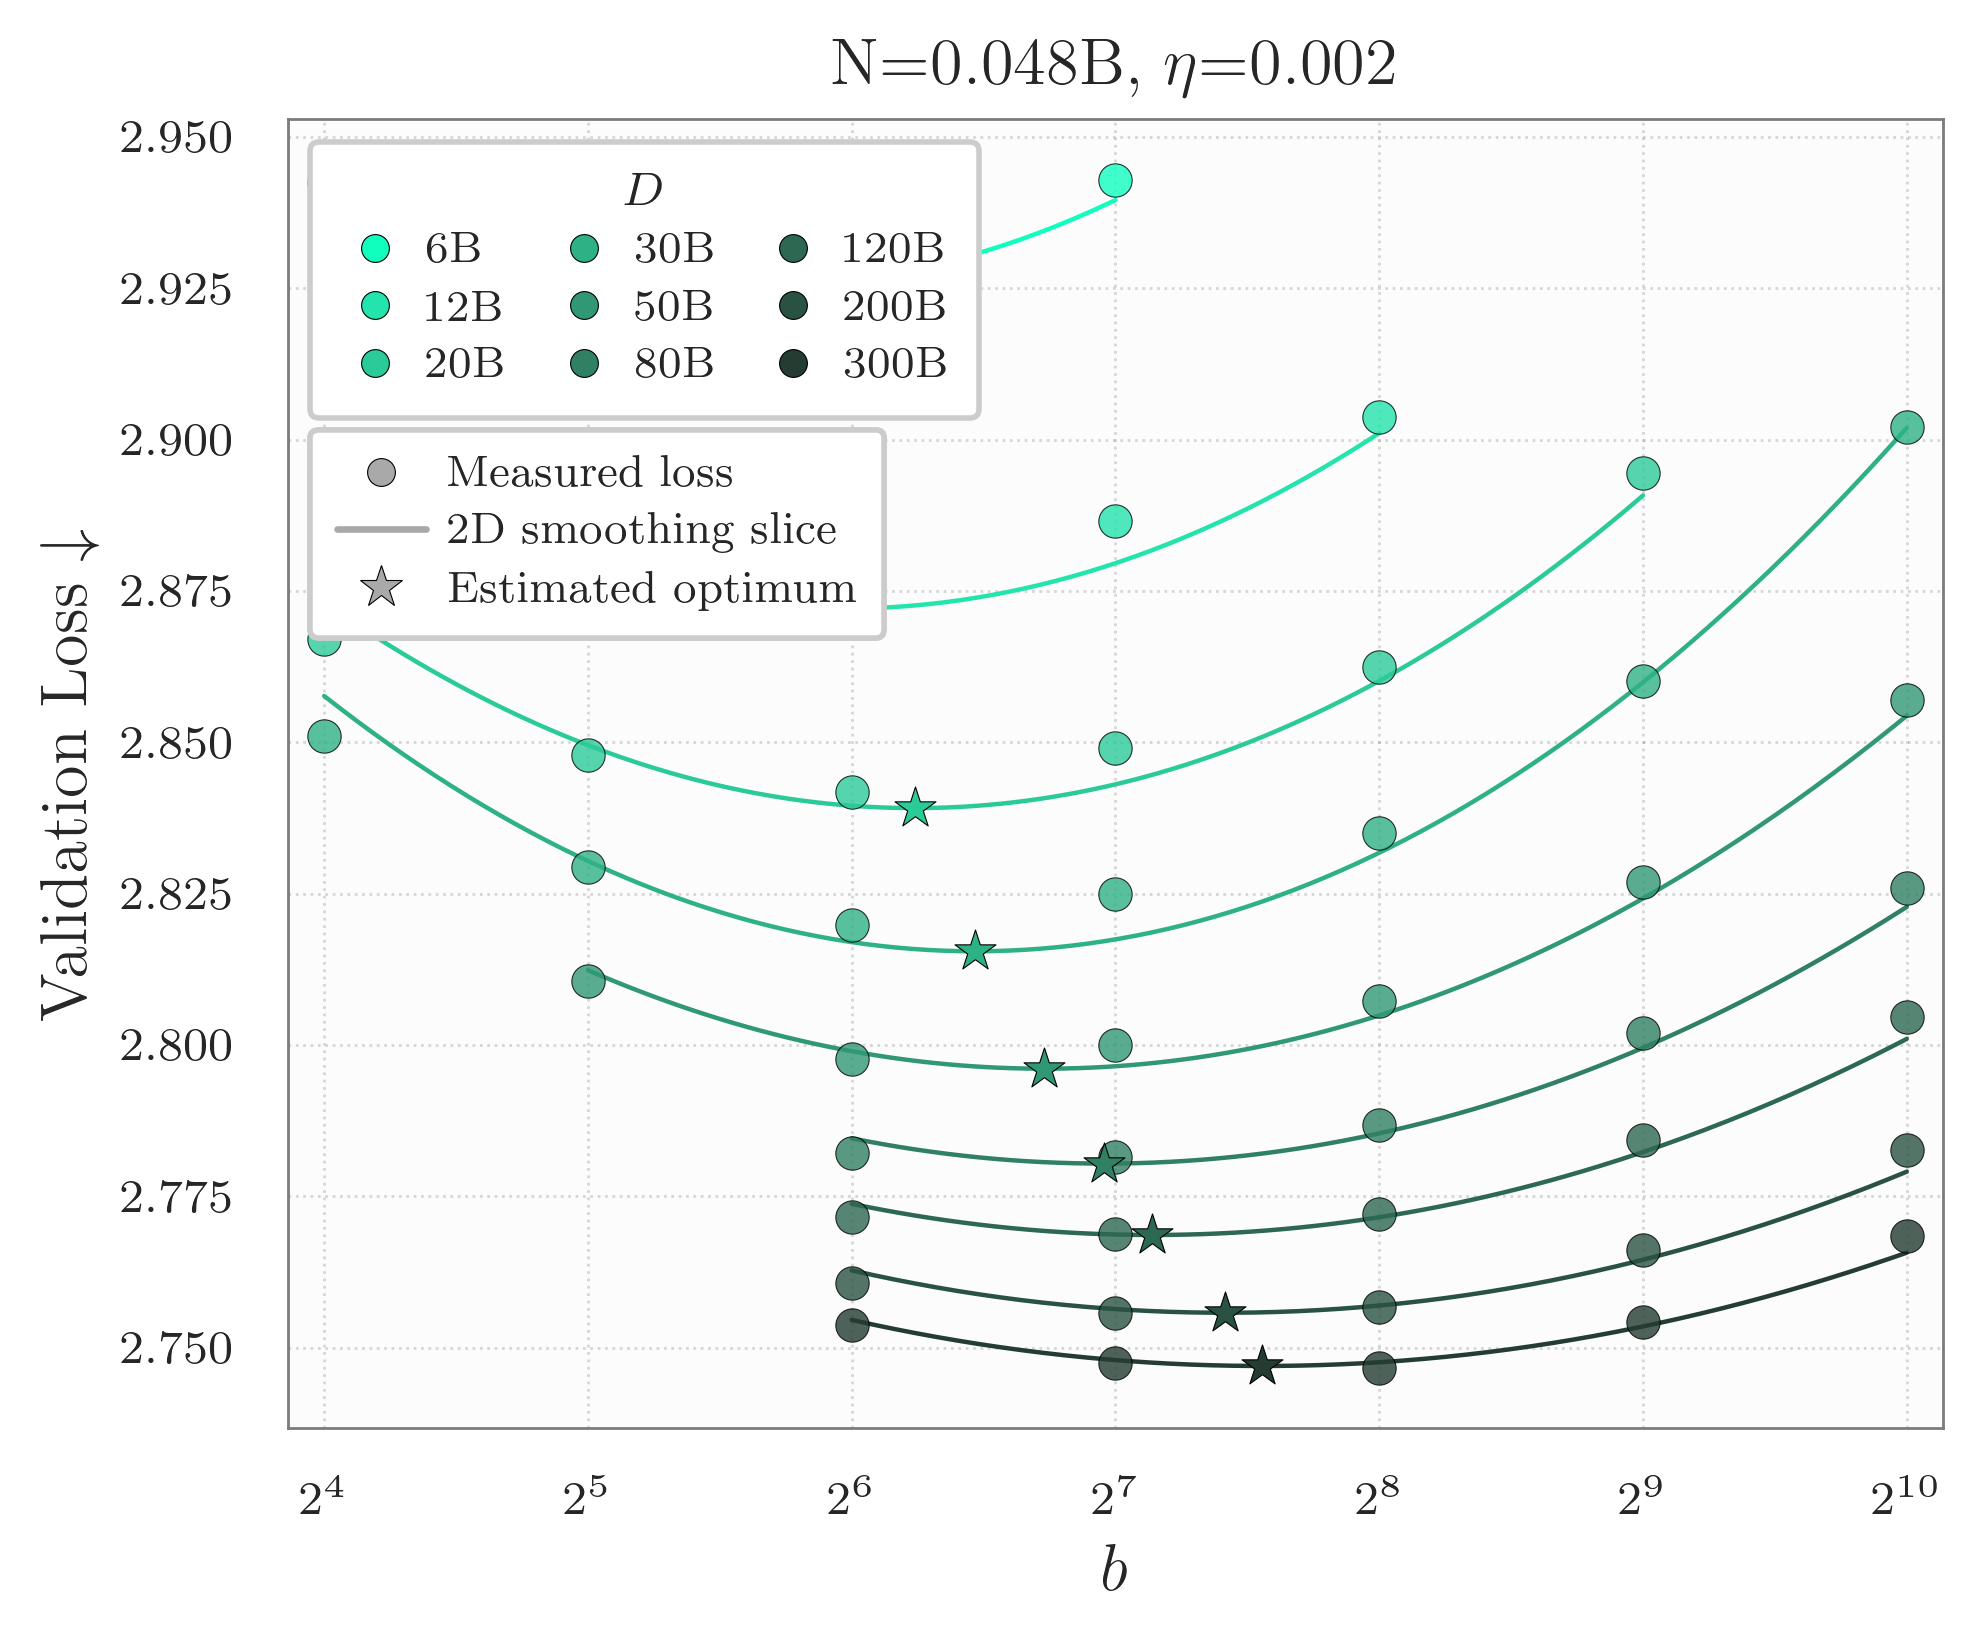

(<Figure size 2000x1660 with 1 Axes>,
 <Axes: title={'center': 'N=0.048B, $\\eta$=0.002'}, xlabel='$b$', ylabel='Validation Loss $\\downarrow$'>)

In [23]:
# ------------------------------------------
# Loss vs batch size, color by D
# ------------------------------------------

N_val = N_approx_to_N[0.05e9]
lr = 0.002

fit_df = fit_2d_sliced_gbsz
fixed_filters = {"N": N_val, "lr": lr}

group_var = "D"
color_map = D_color_map
x_star_col = "gbsz_star"
x_label = r"$b$"
title = f"N={FORMAT_N(N_val)}, $\eta$={lr}"

save_path = '../fig/smoothing/loss_vs_BSZ_hue_D.pdf'

plot_sliced_quadratic(
    df=df,
    fit_df=fit_df,
    fixed_filters=fixed_filters,
    x_var="gbsz",
    group_var=group_var,
    color_map=color_map,
    x_star_col=x_star_col,
    x_label=x_label,
    title=title,
    save_path=save_path,
    show=True,
    ylim_pad=0.01,
    figsize=(5,4.15),
    bbox_to_anchor_2nd_legend=(0.0, 0.78)
)

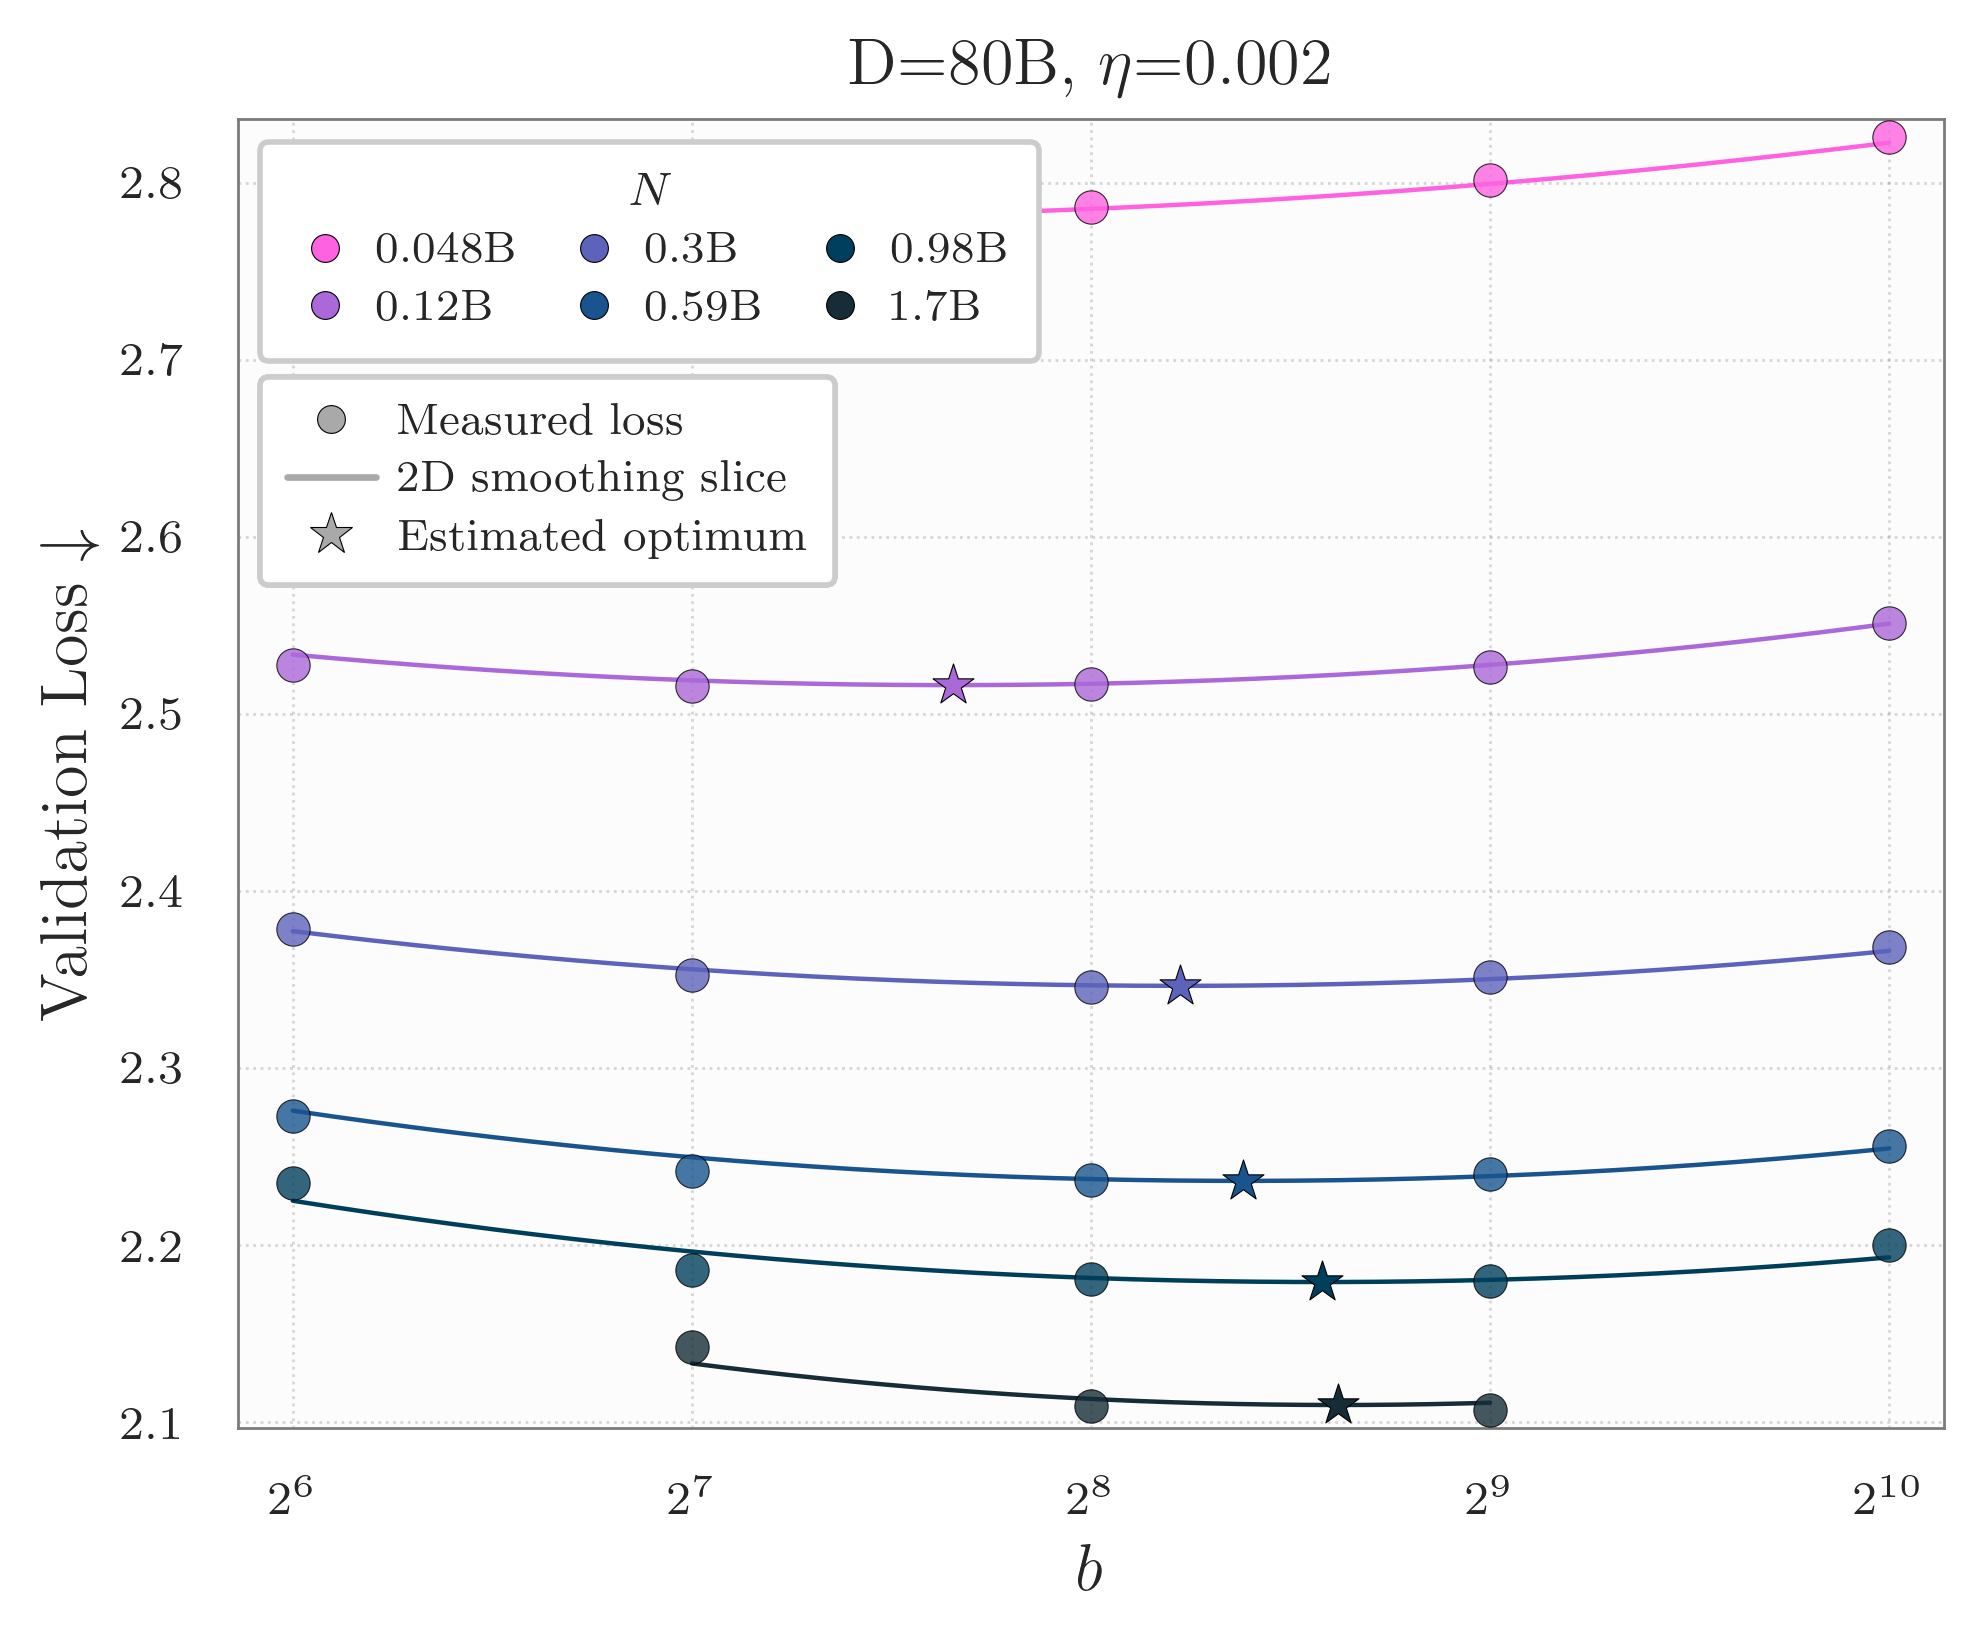

(<Figure size 2000x1660 with 1 Axes>,
 <Axes: title={'center': 'D=80B, $\\eta$=0.002'}, xlabel='$b$', ylabel='Validation Loss $\\downarrow$'>)

In [24]:
# ------------------------------------------
# Loss vs batch size, color by N
# ------------------------------------------

D_val = 80e9
lr = 0.002

fit_df = fit_2d_sliced_gbsz
fixed_filters = {"D": D_val, "lr": lr}

group_var = "N"
color_map = N_color_map
x_star_col = "gbsz_star"
x_label = r"$b$"
title = f"D={FORMAT_D(D_val)}, $\eta$={lr}"

save_path = '../fig/smoothing/loss_vs_BSZ_hue_N.pdf'

plot_sliced_quadratic(
    df=df,
    fit_df=fit_df,
    fixed_filters=fixed_filters,
    x_var="gbsz",
    group_var=group_var,
    color_map=color_map,
    x_star_col=x_star_col,
    x_label=x_label,
    title=title,
    save_path=save_path,
    ylim_pad=0.01,
    show=True,
    figsize=(5,4.15),
    bbox_to_anchor_2nd_legend=(0.0, 0.82)
)